# EV Motor - Remanufacturing Inventory Simulation

This notebook models a closed-loop remanufacturing inventory system for EV motors with:

1. customer demand each week
2. stochastic core returns from fulfilled demand
3. stochastic remanufacturing yield after a reman lead time
4. stochastic supplier lead times for new units
5. a simulation-based reorder policy evaluated with Monte Carlo runs

The notebook now uses a **simulation-based** supplier policy:

- the reorder point is treated as a policy input to test,
- supplier orders are triggered from the simulated state,
- order quantity is based on the simulated **inventory position**,
- pipeline inventory includes stock on hand, supplier units already on order, and expected reman output from active reman jobs.


In [1]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import List, Tuple

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10})
print('Libraries loaded.')

Libraries loaded.


## Parameters

In [2]:
@dataclass
class Params:
    # Inventory limits
    max_stock:          int   = 60     # order-up-to level for supplier replenishment
    initial_stock:      int   = 60     # stock at simulation start

    # Demand
    demand_per_week:    int   = 25     # constant customer demand (units/week)

    # Closed-loop rates
    return_rate:        float = 0.87   # fraction of customers who return old cores
    reman_success_rate: float = 0.90   # fraction of returned cores successfully reman'd
    reman_lead_time:    float = 2.0    # weeks to complete remanufacturing

    # Supplier replenishment policy
    reorder_point:      int   = 35     # trigger supplier review when inventory position <= this value
    lt_mean:            float = 2.0    # supplier lead time mean (weeks)
    lt_std:             float = 0.5    # supplier lead time std dev (weeks)
    review_period:      float = 1.0    # review inventory once per week

    # Cost parameters (euros)
    purchase_cost_per_unit:     float = 2500.0  # supplier purchase cost per unit (€/unit)
    order_cost_per_order:       float = 250.0   # fixed cost each time a supplier order is placed (€/order)
    holding_cost_per_unit_week: float = 100.0   # holding cost per unit per week (€/unit·week)

    # Simulation
    sim_weeks:          int   = 104    # 2 years

In [3]:
p = Params()

# Descriptive averages shown for context only.
net_return_per_week = p.demand_per_week * p.return_rate * p.reman_success_rate
net_supplier_need_per_week = p.demand_per_week - net_return_per_week

print('Baseline settings')
print(f'  Max stock (order-up-to)    : {p.max_stock} units')
print(f'  Initial stock              : {p.initial_stock} units')
print(f'  Reorder point (ROP)        : {p.reorder_point} units')
print(f'  Demand per week            : {p.demand_per_week} units')
print(f'  Avg reman returned/week    : {net_return_per_week:.2f} units')
print(f'  Avg external need/week     : {net_supplier_need_per_week:.2f} units')
print()
print('Policy interpretation')
print('  Review the system every week.')
print('  If simulated inventory position <= ROP, place a supplier order.')
print('  Supplier order quantity = max_stock - inventory_position.')
print('  Inventory position includes stock on hand, supplier units on order,')
print('  and expected reman output from active reman work-in-process.')
print()
print('Cost model used in this notebook')
print('  Total Cost = Purchase Cost (PC) + Ordering Cost (OC) + Holding Cost (HC)')
print(f'  Purchase cost per unit     : \u20ac{p.purchase_cost_per_unit:,.0f}')
print(f'  Order cost per order       : \u20ac{p.order_cost_per_order:,.0f}')
print(f'  Holding cost per unit-week : \u20ac{p.holding_cost_per_unit_week:,.0f}')

Baseline settings
  Max stock (order-up-to)    : 60 units
  Initial stock              : 60 units
  Reorder point (ROP)        : 35 units
  Demand per week            : 25 units
  Avg reman returned/week    : 19.57 units
  Avg external need/week     : 5.43 units

Policy interpretation
  Review the system every week.
  If simulated inventory position <= ROP, place a supplier order.
  Supplier order quantity = max_stock - inventory_position.
  Inventory position includes stock on hand, supplier units on order,
  and expected reman output from active reman work-in-process.

Cost model used in this notebook
  Total Cost = Purchase Cost (PC) + Ordering Cost (OC) + Holding Cost (HC)
  Purchase cost per unit     : €2,500
  Order cost per order       : €250
  Holding cost per unit-week : €100


## SimPy Simulation

In [4]:
class IMSystem:
    """
    Closed-loop remanufacturing inventory system with a simulation-based
    order-up-to supplier policy.

    Processes
    ---------
    weekly_demand   : ships demand, records stockouts, launches reman jobs
    reman_process   : converts returned cores into good units after reman lead time
    reorder_monitor : reviews simulated inventory position once per week
    supplier_order  : supplier delivery arrives after a random lead time
    """

    def __init__(self, env: simpy.Environment, params: Params, rng: np.random.Generator):
        self.env = env
        self.p = params
        self.rng = rng
        self.stock = params.initial_stock
        self.supplier_units_on_order = 0
        self.reman_units_in_process = 0

        # Log lists
        self.log_time: List[float] = []
        self.log_stock: List[int] = []
        self.log_inventory_position: List[float] = []
        self.log_reman_wip_expected: List[float] = []
        self.log_demand: List[Tuple] = []            # (week, qty)
        self.log_stockouts: List[Tuple] = []         # (week, units_short)
        self.log_reman_in: List[Tuple] = []          # (week, units_added)
        self.log_orders: List[Tuple] = []            # (week_placed, qty, week_arrived)
        self.log_supplier_in: List[Tuple] = []       # (week, units_added)

        self._snap()

        env.process(self.weekly_demand())
        env.process(self.reorder_monitor())

    def expected_reman_pipeline(self) -> float:
        # Active reman jobs are still stochastic, so we use expected good output from
        # the current WIP as part of pipeline inventory seen by the supplier policy.
        return self.reman_units_in_process * self.p.reman_success_rate

    def inventory_position(self) -> float:
        # Pipeline-aware inventory position used for ordering decisions.
        return self.stock + self.supplier_units_on_order + self.expected_reman_pipeline()

    def _snap(self):
        self.log_time.append(self.env.now)
        self.log_stock.append(self.stock)
        self.log_inventory_position.append(self.inventory_position())
        self.log_reman_wip_expected.append(self.expected_reman_pipeline())

    def _add_to_stock(self, qty: int):
        self.stock += qty
        return qty

    def weekly_demand(self):
        while True:
            yield self.env.timeout(1)
            week = self.env.now

            demand = self.p.demand_per_week
            fulfilled = min(demand, self.stock)
            short = demand - fulfilled

            self.stock -= fulfilled
            self.log_demand.append((week, demand))

            if short > 0:
                self.log_stockouts.append((week, short))

            self._snap()

            cores_back = int(self.rng.binomial(fulfilled, self.p.return_rate))
            if cores_back > 0:
                self.reman_units_in_process += cores_back
                self._snap()
                self.env.process(self.reman_process(cores_back))

    def reman_process(self, n_cores: int):
        yield self.env.timeout(self.p.reman_lead_time)

        self.reman_units_in_process -= n_cores
        good_units = int(self.rng.binomial(n_cores, self.p.reman_success_rate))
        added = self._add_to_stock(good_units)

        self.log_reman_in.append((self.env.now, added))
        self._snap()

    def reorder_monitor(self):
        while True:
            yield self.env.timeout(self.p.review_period)

            inv_pos = self.inventory_position()
            if inv_pos <= self.p.reorder_point:
                order_qty = max(0, int(round(self.p.max_stock - inv_pos)))
                if order_qty == 0:
                    continue

                self.supplier_units_on_order += order_qty
                record = [self.env.now, order_qty, None]
                self.log_orders.append(record)
                self.env.process(self.supplier_order(order_qty, record))
                self._snap()

    def supplier_order(self, qty: int, record: list):
        lead_time = max(0.1, float(self.rng.normal(self.p.lt_mean, self.p.lt_std)))
        yield self.env.timeout(lead_time)

        self.supplier_units_on_order -= qty
        self._add_to_stock(qty)
        record[2] = self.env.now
        self.log_supplier_in.append((self.env.now, qty))
        self._snap()


def run(params: Params = None, seed: int = 42) -> IMSystem:
    if params is None:
        params = Params()
    rng = np.random.default_rng(seed)
    env = simpy.Environment()
    system = IMSystem(env, params, rng)
    env.run(until=params.sim_weeks)
    return system


print('Simulation class defined.')
print()
print('Simulation-based supplier policy')
print(f'  Review period              : {p.review_period} week')
print(f'  Reorder point              : {p.reorder_point} units')
print(f'  Order-up-to level          : {p.max_stock} units')
print('  Inventory position         : stock + supplier units on order + expected reman WIP output')
print('  Supplier order quantity    : max_stock - inventory_position when triggered')


Simulation class defined.

Simulation-based supplier policy
  Review period              : 1.0 week
  Reorder point              : 35 units
  Order-up-to level          : 60 units
  Inventory position         : stock + supplier units on order + expected reman WIP output
  Supplier order quantity    : max_stock - inventory_position when triggered


## Single Run — Inventory Trajectory

In [5]:
sys = run(p, seed=42)

# KPIs
filled_demand     = sum(d[1] for d in sys.log_demand) - sum(s[1] for s in sys.log_stockouts)
total_demand      = sum(d[1] for d in sys.log_demand)
total_stockouts   = sum(s[1] for s in sys.log_stockouts)
service_level     = filled_demand / total_demand if total_demand else 1.0
n_orders          = len(sys.log_orders)
total_reman_in    = sum(r[1] for r in sys.log_reman_in)
total_supplier_in = sum(r[1] for r in sys.log_supplier_in)
avg_stock         = float(np.mean(sys.log_stock))
avg_inv_pos       = float(np.mean(sys.log_inventory_position))
avg_reman_wip_exp = float(np.mean(sys.log_reman_wip_expected))
avg_order_qty     = float(np.mean([o[1] for o in sys.log_orders])) if sys.log_orders else 0.0

# Cost breakdown
purchase_cost = total_supplier_in * p.purchase_cost_per_unit
ordering_cost = n_orders * p.order_cost_per_order
holding_cost  = avg_stock * p.holding_cost_per_unit_week * p.sim_weeks
total_cost    = purchase_cost + ordering_cost + holding_cost

print('=' * 56)
print(f'  Simulation weeks          : {p.sim_weeks}')
print(f'  Total demand              : {total_demand} units')
print(f'  Filled demand             : {filled_demand} units')
print(f'  Total stockouts           : {total_stockouts} units  ({len(sys.log_stockouts)} events)')
print(f'  Service level             : {service_level:.1%}')
print(f'  Reman units restocked     : {total_reman_in}')
print(f'  Supplier units delivered  : {total_supplier_in}')
print(f'  Supplier orders placed    : {n_orders}')
print(f'  Avg order quantity        : {avg_order_qty:.1f} units')
print(f'  Avg stock on hand         : {avg_stock:.1f} units')
print(f'  Avg inventory position    : {avg_inv_pos:.1f} units')
print(f'  Avg expected reman WIP    : {avg_reman_wip_exp:.1f} units')
print('-' * 56)
print(f'  Purchase cost (PC)        : \u20ac{purchase_cost:,.2f}')
print(f'  Ordering cost (OC)        : \u20ac{ordering_cost:,.2f}')
print(f'  Holding cost (HC)         : \u20ac{holding_cost:,.2f}')
print(f'  Total cost                : \u20ac{total_cost:,.2f}')
print('=' * 56)

  Simulation weeks          : 104
  Total demand              : 2575 units
  Filled demand             : 2230 units
  Total stockouts           : 345 units  (60 events)
  Service level             : 86.6%
  Reman units restocked     : 1728
  Supplier units delivered  : 442
  Supplier orders placed    : 17
  Avg order quantity        : 27.5 units
  Avg stock on hand         : 11.2 units
  Avg inventory position    : 41.8 units
  Avg expected reman WIP    : 23.4 units
--------------------------------------------------------
  Purchase cost (PC)        : €1,105,000.00
  Ordering cost (OC)        : €4,250.00
  Holding cost (HC)         : €116,199.41
  Total cost                : €1,225,449.41


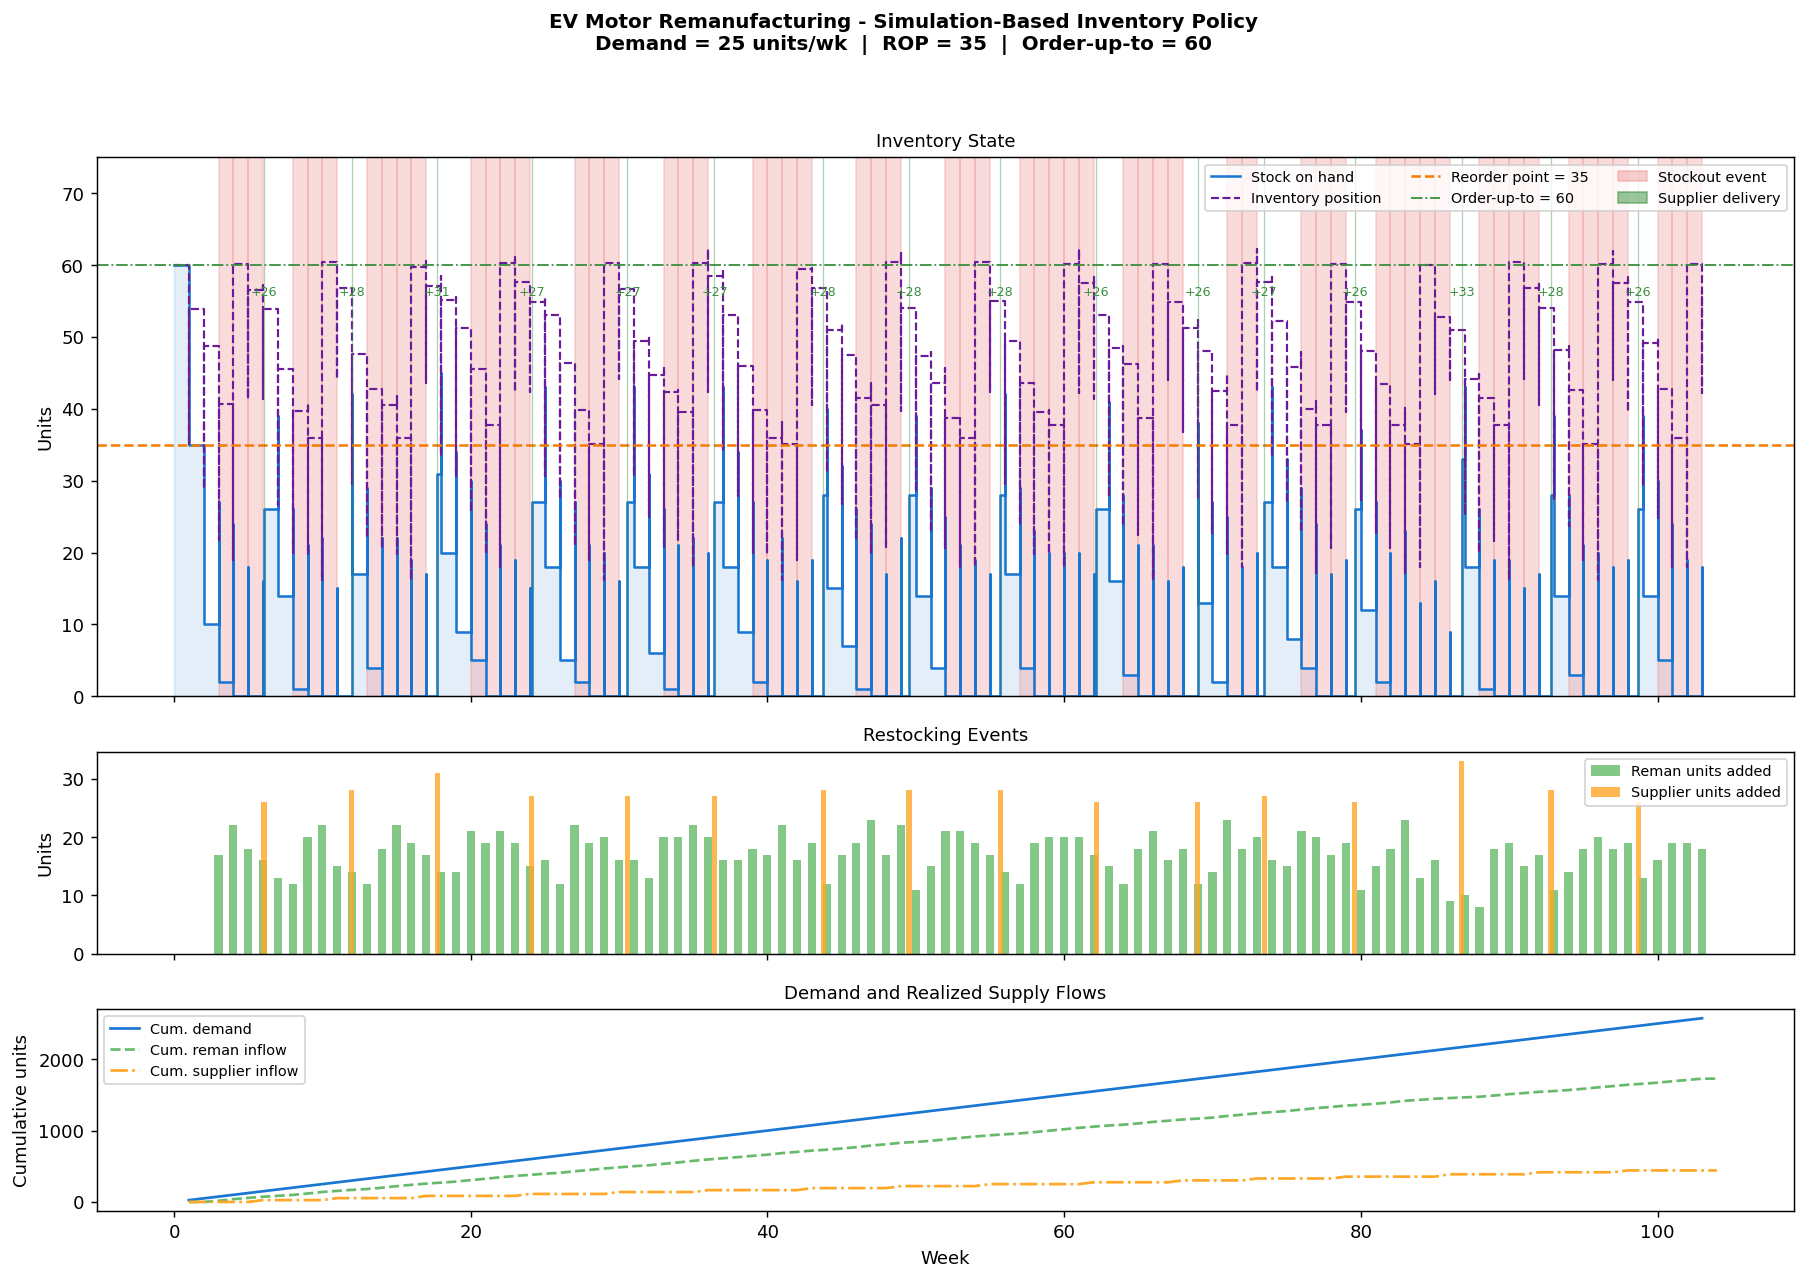

Plot saved: inventory_run.png


In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [4, 1.5, 1.5]},
                         sharex=True)
fig.suptitle('EV Motor Remanufacturing - Simulation-Based Inventory Policy\n'
             f'Demand = {p.demand_per_week} units/wk  |  ROP = {p.reorder_point}  |  '
             f'Order-up-to = {p.max_stock}',
             fontsize=11, fontweight='bold')

# Panel 1: stock level and inventory position
ax = axes[0]
ax.step(sys.log_time, sys.log_stock, where='post', lw=1.4,
        color='#1976D2', label='Stock on hand')
ax.step(sys.log_time, sys.log_inventory_position, where='post', lw=1.2,
        color='#6A1B9A', linestyle='--', label='Inventory position')
ax.fill_between(sys.log_time, sys.log_stock,
                step='post', alpha=0.12, color='#1976D2')
ax.axhline(p.reorder_point, color='#F57C00', lw=1.4, ls='--',
           label=f'Reorder point = {p.reorder_point}')
ax.axhline(p.max_stock, color='#388E3C', lw=1.0, ls='-.',
           label=f'Order-up-to = {p.max_stock}')

for placed, qty, arrived in sys.log_orders:
    if arrived is not None:
        ax.axvline(arrived, color='#388E3C', lw=0.7, alpha=0.4)
        ax.annotate(f'+{qty}', xy=(arrived, p.max_stock * 0.93),
                    fontsize=7, color='#388E3C', ha='center')

for week, short in sys.log_stockouts:
    ax.axvspan(week - 1, week, color='#EF9A9A', alpha=0.35)

red_patch = mpatches.Patch(color='#EF9A9A', alpha=0.5, label='Stockout event')
green_line = mpatches.Patch(color='#388E3C', alpha=0.5, label='Supplier delivery')
ax.legend(handles=ax.get_legend_handles_labels()[0] + [red_patch, green_line],
          fontsize=8, loc='upper right', ncol=3)
ax.set_ylabel('Units')
ax.set_ylim(0, p.max_stock + 15)
ax.set_title('Inventory State', fontsize=10)

# Panel 2: inflows from reman and supplier
ax2 = axes[1]
if sys.log_reman_in:
    reman_weeks, reman_qty = zip(*sys.log_reman_in)
    ax2.bar(reman_weeks, reman_qty, width=0.55, color='#66BB6A',
            alpha=0.8, label='Reman units added')
if sys.log_supplier_in:
    supplier_weeks, supplier_qty = zip(*sys.log_supplier_in)
    ax2.bar(supplier_weeks, supplier_qty, width=0.35, color='#FFA726',
            alpha=0.8, label='Supplier units added')
ax2.set_ylabel('Units')
ax2.set_title('Restocking Events', fontsize=10)
ax2.legend(fontsize=8)

# Panel 3: cumulative demand vs realized replenishment
ax3 = axes[2]
demand_weeks = [d[0] for d in sys.log_demand]
cum_demand = np.cumsum([d[1] for d in sys.log_demand])
reman_series = pd.Series(0, index=range(1, p.sim_weeks + 1))
supplier_series = pd.Series(0, index=range(1, p.sim_weeks + 1))
for wk, qty in sys.log_reman_in:
    wk_int = int(wk)
    if wk_int in reman_series.index:
        reman_series[wk_int] += qty
for wk, qty in sys.log_supplier_in:
    wk_int = int(wk)
    if wk_int in supplier_series.index:
        supplier_series[wk_int] += qty
cum_reman = reman_series.cumsum()
cum_supplier = supplier_series.cumsum()

ax3.plot(demand_weeks, cum_demand, color='#1976D2', lw=1.5, label='Cum. demand')
ax3.plot(cum_reman.index, cum_reman.values, color='#66BB6A',
         lw=1.5, ls='--', label='Cum. reman inflow')
ax3.plot(cum_supplier.index, cum_supplier.values, color='#FFA726',
         lw=1.5, ls='-.', label='Cum. supplier inflow')
ax3.set_xlabel('Week')
ax3.set_ylabel('Cumulative units')
ax3.set_title('Demand and Realized Supply Flows', fontsize=10)
ax3.legend(fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('inventory_run.png', bbox_inches='tight')
plt.show()
print('Plot saved: inventory_run.png')


## Interactive Policy Explorer

Use the sliders below to tune key parameters and see the inventory trajectory and KPIs update instantly.

In [7]:
import ipywidgets as widgets
from IPython.display import display

# ── widget controls ────────────────────────────────────────────────────────
w_rop      = widgets.IntSlider(value=35,  min=10,  max=60,  step=1,    description='ROP',              style={'description_width':'110px'}, layout=widgets.Layout(width='420px'))
w_maxs     = widgets.IntSlider(value=60,  min=20,  max=120, step=5,    description='Order-up-to (S)',  style={'description_width':'110px'}, layout=widgets.Layout(width='420px'))
w_demand   = widgets.IntSlider(value=25,  min=5,   max=60,  step=1,    description='Demand/wk',        style={'description_width':'110px'}, layout=widgets.Layout(width='420px'))
w_rr       = widgets.FloatSlider(value=0.87, min=0.3, max=1.0, step=0.01, description='Return rate',  style={'description_width':'110px'}, layout=widgets.Layout(width='420px'), readout_format='.2f')
w_rsr      = widgets.FloatSlider(value=0.90, min=0.3, max=1.0, step=0.01, description='Reman yield',  style={'description_width':'110px'}, layout=widgets.Layout(width='420px'), readout_format='.2f')
w_rlt      = widgets.FloatSlider(value=2.0,  min=1.0, max=8.0, step=0.5,  description='Reman LT (wk)',style={'description_width':'110px'}, layout=widgets.Layout(width='420px'), readout_format='.1f')
w_ltm      = widgets.FloatSlider(value=2.0,  min=0.5, max=6.0, step=0.5,  description='Supplier LT', style={'description_width':'110px'}, layout=widgets.Layout(width='420px'), readout_format='.1f')
w_seed     = widgets.IntSlider(value=42,  min=0,   max=200, step=1,    description='Seed',             style={'description_width':'110px'}, layout=widgets.Layout(width='420px'))

col1 = widgets.VBox([w_rop, w_maxs, w_demand, w_seed])
col2 = widgets.VBox([w_rr,  w_rsr,  w_rlt,    w_ltm])
controls = widgets.HBox([col1, col2])

out = widgets.Output()

# ── update function ────────────────────────────────────────────────────────
def update(_change=None):
    p2 = Params(
        reorder_point      = w_rop.value,
        max_stock          = w_maxs.value,
        initial_stock      = w_maxs.value,
        demand_per_week    = w_demand.value,
        return_rate        = w_rr.value,
        reman_success_rate = w_rsr.value,
        reman_lead_time    = w_rlt.value,
        lt_mean            = w_ltm.value,
    )

    s2 = run(p2, seed=w_seed.value)

    # KPIs
    filled   = sum(d[1] for d in s2.log_demand) - sum(x[1] for x in s2.log_stockouts)
    total_d  = sum(d[1] for d in s2.log_demand)
    sl       = filled / total_d if total_d else 1.0
    n_orders = len(s2.log_orders)
    t_reman  = sum(r[1] for r in s2.log_reman_in)
    t_sup    = sum(r[1] for r in s2.log_supplier_in)
    avg_stk  = float(np.mean(s2.log_stock))

    pc = t_sup    * p2.purchase_cost_per_unit
    oc = n_orders * p2.order_cost_per_order
    hc = avg_stk  * p2.holding_cost_per_unit_week * p2.sim_weeks
    tc = pc + oc + hc

    with out:
        out.clear_output(wait=True)

        fig, axes = plt.subplots(2, 1, figsize=(14, 7),
                                 gridspec_kw={'height_ratios': [3, 1.2]},
                                 sharex=True)
        fig.suptitle(
            f'ROP={p2.reorder_point}  S={p2.max_stock}  '
            f'Demand={p2.demand_per_week}/wk  '
            f'Return={p2.return_rate:.0%}  Yield={p2.reman_success_rate:.0%}\n'
            f'SL={sl:.1%}  Stockouts={sum(x[1] for x in s2.log_stockouts)} units  '
            f'Orders={n_orders}  Avg stock={avg_stk:.1f}  Total cost=\u20ac{tc:,.0f}',
            fontsize=10, fontweight='bold'
        )

        # ── panel 1: stock + inventory position ──────────────────────────
        ax = axes[0]
        ax.step(s2.log_time, s2.log_stock, where='post', lw=1.4,
                color='#1976D2', label='Stock on hand')
        ax.step(s2.log_time, s2.log_inventory_position, where='post', lw=1.1,
                color='#6A1B9A', ls='--', label='Inventory position')
        ax.fill_between(s2.log_time, s2.log_stock, step='post',
                        alpha=0.10, color='#1976D2')
        ax.axhline(p2.reorder_point, color='#F57C00', lw=1.3, ls='--',
                   label=f'ROP={p2.reorder_point}')
        ax.axhline(p2.max_stock, color='#388E3C', lw=1.0, ls='-.',
                   label=f'S={p2.max_stock}')

        for placed, qty, arrived in s2.log_orders:
            if arrived is not None:
                ax.axvline(arrived, color='#388E3C', lw=0.6, alpha=0.35)

        for week, short in s2.log_stockouts:
            ax.axvspan(week - 1, week, color='#EF9A9A', alpha=0.30)

        so_patch = mpatches.Patch(color='#EF9A9A', alpha=0.5, label='Stockout')
        ax.legend(handles=ax.get_legend_handles_labels()[0] + [so_patch],
                  fontsize=8, loc='upper right', ncol=4)
        ax.set_ylabel('Units')
        ax.set_ylim(0, max(p2.max_stock + 20, max(s2.log_stock) + 10))

        # ── panel 2: reman vs supplier inflows ───────────────────────────
        ax2 = axes[1]
        if s2.log_reman_in:
            rw, rq = zip(*s2.log_reman_in)
            ax2.bar(rw, rq, width=0.55, color='#66BB6A', alpha=0.8, label=f'Reman ({t_reman} total)')
        if s2.log_supplier_in:
            sw, sq = zip(*s2.log_supplier_in)
            ax2.bar(sw, sq, width=0.35, color='#FFA726', alpha=0.8, label=f'Supplier ({t_sup} total)')
        ax2.set_ylabel('Units')
        ax2.set_xlabel('Week')
        ax2.legend(fontsize=8)

        plt.tight_layout(rect=[0, 0, 1, 0.92])
        plt.show()

# ── wire up all sliders ────────────────────────────────────────────────────
for w in [w_rop, w_maxs, w_demand, w_rr, w_rsr, w_rlt, w_ltm, w_seed]:
    w.observe(update, names='value')

display(controls, out)
update()   # draw immediately

Output()

## Sensitivity Analysis

Four systematic analyses complement the interactive widget above:
1. **ROP Sweep** — how does policy choice trade off SL vs cost?
2. **Closed-Loop Rate Sensitivity** — what happens when return or yield rates degrade?
3. **Tornado Chart (OAT ±30%)** — which parameters matter most?
4. **(ROP, S) Pareto Frontier** — what is the full cost–service tradeoff surface?

In [8]:
import dataclasses

# ── KPI extractor ─────────────────────────────────────────────────────────
def kpi_from_run(sys, p):
    filled    = sum(d[1] for d in sys.log_demand) - sum(s[1] for s in sys.log_stockouts)
    total_d   = sum(d[1] for d in sys.log_demand)
    n_orders  = len(sys.log_orders)
    t_sup     = sum(r[1] for r in sys.log_supplier_in)
    avg_stk   = float(np.mean(sys.log_stock))
    pc = t_sup    * p.purchase_cost_per_unit
    oc = n_orders * p.order_cost_per_order
    hc = avg_stk  * p.holding_cost_per_unit_week * p.sim_weeks
    return dict(
        service_level     = filled / total_d if total_d else 1.0,
        total_stockouts   = sum(s[1] for s in sys.log_stockouts),
        avg_stock         = avg_stk,
        avg_inv_pos       = float(np.mean(sys.log_inventory_position)),
        purchase_cost     = pc,
        ordering_cost     = oc,
        holding_cost      = hc,
        total_cost        = pc + oc + hc,
        n_orders          = n_orders,
        total_supplier_in = t_sup,
    )

# ── shared constants ──────────────────────────────────────────────────────
N_REPS   = 20
BASELINE = Params()   # canonical reference — never mutate

print(f'Helper ready.  N_REPS={N_REPS}  |  Baseline: ROP={BASELINE.reorder_point}, S={BASELINE.max_stock}, '
      f'c_p=€{BASELINE.purchase_cost_per_unit:,.0f}, c_h=€{BASELINE.holding_cost_per_unit_week}/unit·wk')

Helper ready.  N_REPS=20  |  Baseline: ROP=35, S=60, c_p=€2,500, c_h=€100.0/unit·wk


### Analysis 1: ROP Sweep

Sweep `reorder_point` from 10 to 58 (step 2) while fixing $S = 60$.  
Each point uses **N=20 Monte Carlo replications** to average out stochastic noise.  
The dual-axis chart shows how raising ROP improves service level but also raises total cost.

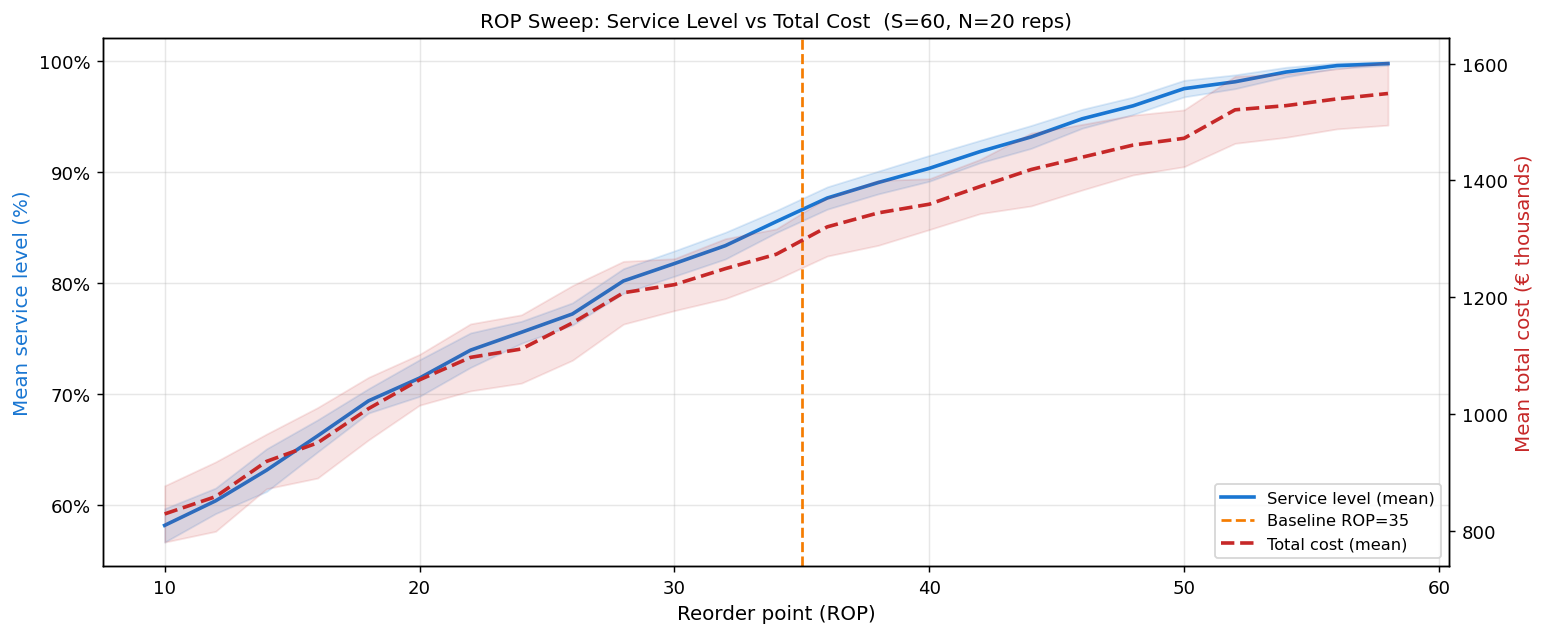

Highest SL: ROP=58  →  SL=99.8%  TC=€1,548,937


In [9]:
ROP_VALUES = range(10, 60, 2)
S_FIXED    = 60

records = []
for rop in ROP_VALUES:
    p_var = Params(reorder_point=rop, max_stock=S_FIXED, initial_stock=S_FIXED)
    batch = [kpi_from_run(run(p_var, seed=s), p_var) for s in range(N_REPS)]
    df_b  = pd.DataFrame(batch)
    records.append(dict(
        reorder_point = rop,
        sl_mean       = df_b.service_level.mean(),
        sl_std        = df_b.service_level.std(),
        cost_mean     = df_b.total_cost.mean(),
        cost_std      = df_b.total_cost.std(),
    ))
df_rop = pd.DataFrame(records)

# ── plot ──────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

x = df_rop.reorder_point
ax1.plot(x, df_rop.sl_mean * 100, color='#1976D2', lw=2, label='Service level (mean)')
ax1.fill_between(x,
                 (df_rop.sl_mean - df_rop.sl_std) * 100,
                 (df_rop.sl_mean + df_rop.sl_std) * 100,
                 alpha=0.15, color='#1976D2')
ax2.plot(x, df_rop.cost_mean / 1e3, color='#C62828', lw=2, ls='--', label='Total cost (mean)')
ax2.fill_between(x,
                 (df_rop.cost_mean - df_rop.cost_std) / 1e3,
                 (df_rop.cost_mean + df_rop.cost_std) / 1e3,
                 alpha=0.12, color='#C62828')

ax1.axvline(BASELINE.reorder_point, color='#F57C00', lw=1.5, ls='--',
            label=f'Baseline ROP={BASELINE.reorder_point}')
ax1.set_xlabel('Reorder point (ROP)', fontsize=11)
ax1.set_ylabel('Mean service level (%)', color='#1976D2', fontsize=11)
ax2.set_ylabel('Mean total cost (€ thousands)', color='#C62828', fontsize=11)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='lower right')
ax1.set_title(f'ROP Sweep: Service Level vs Total Cost  (S={S_FIXED}, N={N_REPS} reps)', fontsize=11)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best = df_rop.loc[df_rop.sl_mean.idxmax()]
print(f'Highest SL: ROP={int(best.reorder_point)}  →  SL={best.sl_mean:.1%}  TC=€{best.cost_mean:,.0f}')

### Analysis 2: Closed-Loop Supply Sensitivity

Sweep `return_rate` ($p_r$: 0.50→0.95) and `reman_success_rate` ($p_y$: 0.60→0.99) independently, all other parameters at baseline.  
**Left panel:** how quickly does SL fall as closed-loop recovery degrades?  
**Right panel:** how many additional supplier units must be purchased to compensate — the external cost exposure.

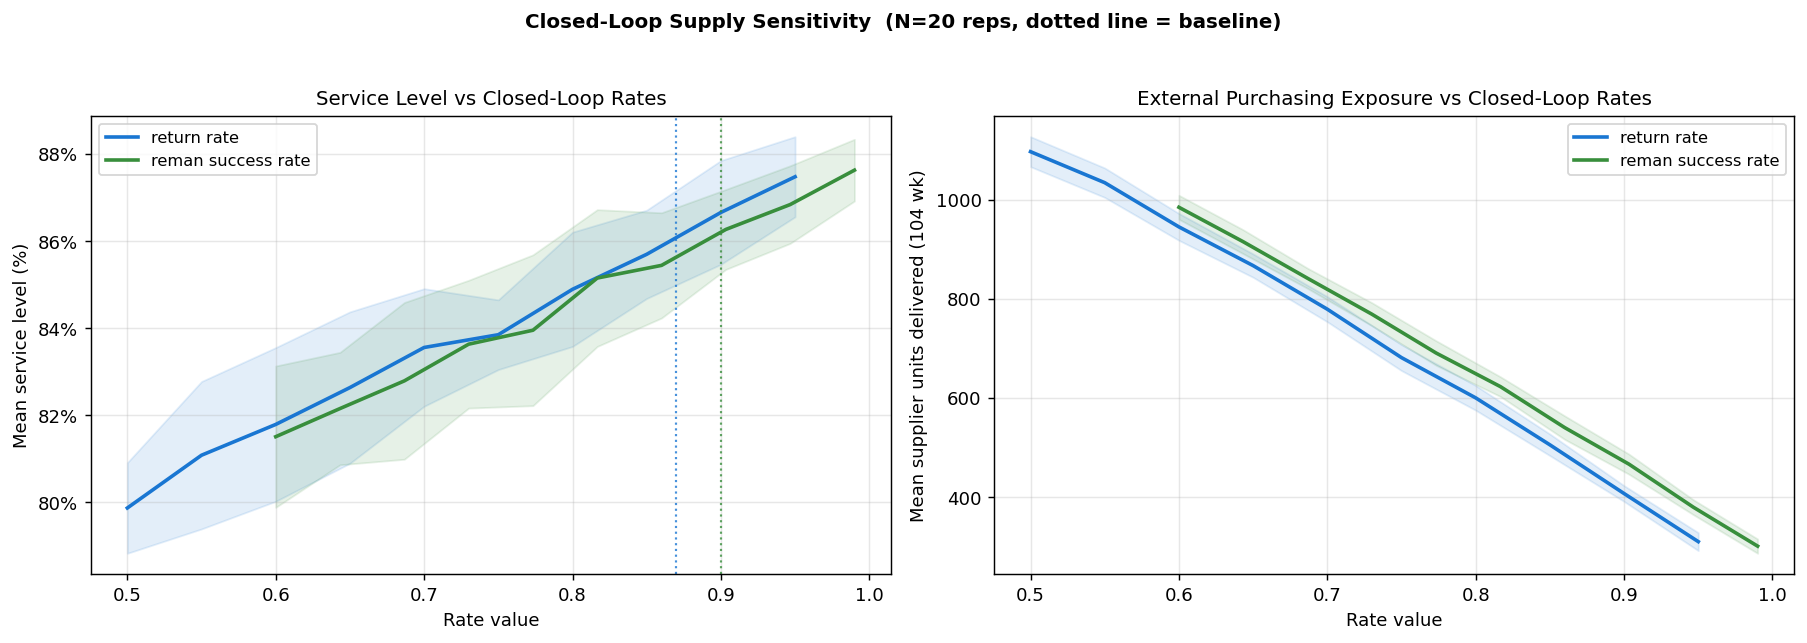

In [10]:
def sweep_param(name, values):
    out = []
    for v in values:
        p_var = dataclasses.replace(BASELINE, **{name: v})
        batch = [kpi_from_run(run(p_var, seed=s), p_var) for s in range(N_REPS)]
        df_b  = pd.DataFrame(batch)
        out.append({
            name:             v,
            'sl_mean':        df_b.service_level.mean(),
            'sl_std':         df_b.service_level.std(),
            'supplier_mean':  df_b.total_supplier_in.mean(),
            'supplier_std':   df_b.total_supplier_in.std(),
        })
    return pd.DataFrame(out)

df_rr  = sweep_param('return_rate',        np.linspace(0.50, 0.95, 10))
df_rsr = sweep_param('reman_success_rate', np.linspace(0.60, 0.99, 10))

# ── plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, name, color, base_v in [
    (axes[0], df_rr,  'return_rate',        '#1976D2', BASELINE.return_rate),
    (axes[0], df_rsr, 'reman_success_rate', '#388E3C', BASELINE.reman_success_rate),
]:
    x = df[name]
    ax.plot(x, df.sl_mean * 100, color=color, lw=2, label=name.replace('_', ' '))
    ax.fill_between(x,
                    (df.sl_mean - df.sl_std) * 100,
                    (df.sl_mean + df.sl_std) * 100,
                    alpha=0.12, color=color)
    ax.axvline(base_v, color=color, lw=1.2, ls=':', alpha=0.8)

axes[0].set_xlabel('Rate value', fontsize=10)
axes[0].set_ylabel('Mean service level (%)', fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
axes[0].set_title('Service Level vs Closed-Loop Rates', fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

for ax, df, name, color in [
    (axes[1], df_rr,  'return_rate',        '#1976D2'),
    (axes[1], df_rsr, 'reman_success_rate', '#388E3C'),
]:
    x = df[name]
    ax.plot(x, df.supplier_mean, color=color, lw=2, label=name.replace('_', ' '))
    ax.fill_between(x,
                    df.supplier_mean - df.supplier_std,
                    df.supplier_mean + df.supplier_std,
                    alpha=0.12, color=color)

axes[1].set_xlabel('Rate value', fontsize=10)
axes[1].set_ylabel('Mean supplier units delivered (104 wk)', fontsize=10)
axes[1].set_title('External Purchasing Exposure vs Closed-Loop Rates', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Closed-Loop Supply Sensitivity  (N={N_REPS} reps, dotted line = baseline)',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Analysis 3: Tornado Chart (±30% OAT)

Each of 6 parameters is perturbed **±30% from its baseline** while all others are held fixed.  
The resulting % change in **SL** and **total cost** is measured with N=20 replications.  
The widest bars identify which parameters have the greatest leverage — the key finding for management.

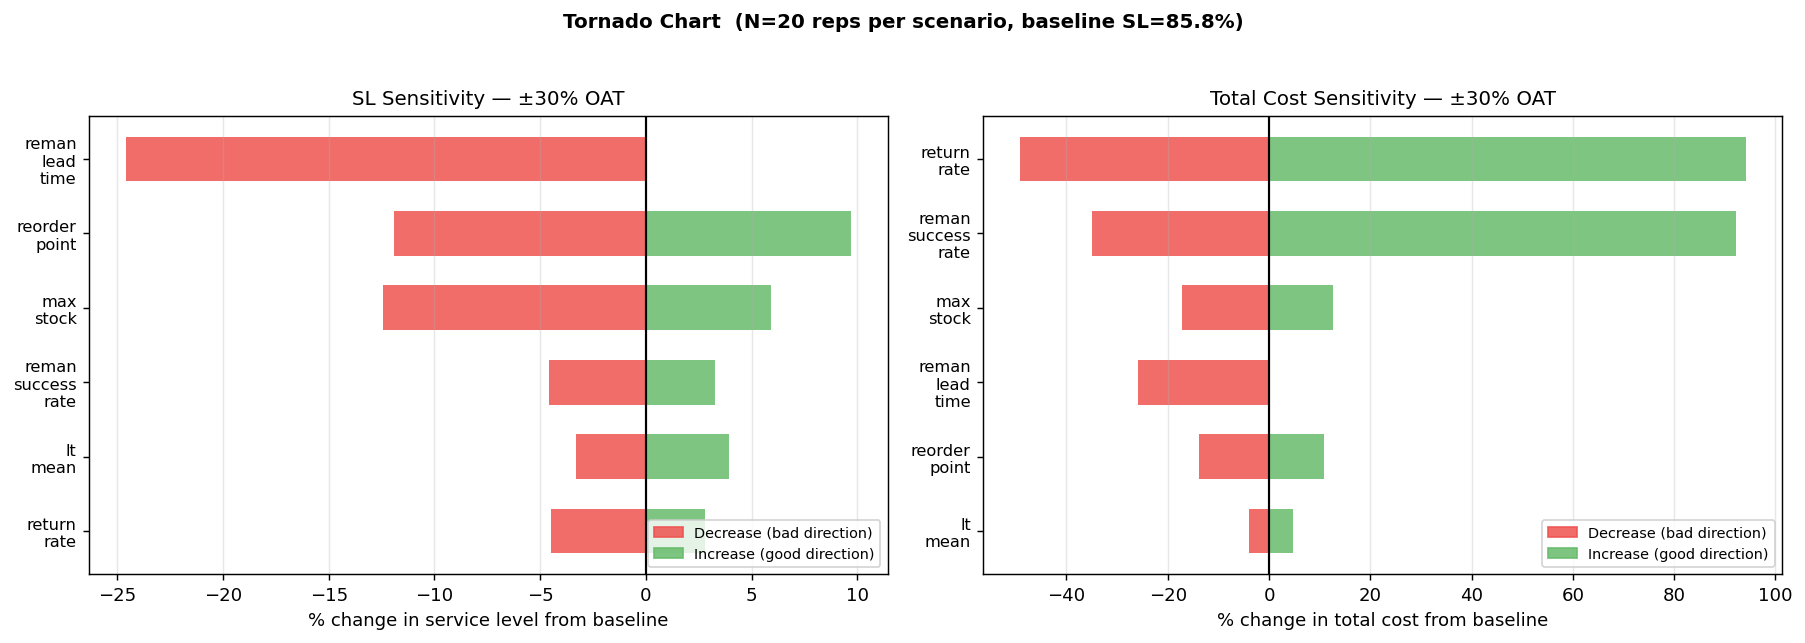

In [11]:
TORNADO_PARAMS = ['reorder_point', 'max_stock', 'return_rate',
                  'reman_success_rate', 'lt_mean', 'reman_lead_time']
DELTA = 0.30

# ── Monte Carlo baseline (fresh N_REPS runs for stable denominator) ───────
base_batch = [kpi_from_run(run(BASELINE, s), BASELINE) for s in range(N_REPS)]
base_df    = pd.DataFrame(base_batch)
base_sl    = base_df.service_level.mean()
base_cost  = base_df.total_cost.mean()

# ── OAT sweep ─────────────────────────────────────────────────────────────
records = []
for param in TORNADO_PARAMS:
    base_val = getattr(BASELINE, param)
    for direction, sign in [('low', -1), ('high', +1)]:
        perturbed = type(base_val)(base_val * (1 + sign * DELTA))
        # clip probability parameters to valid [0, 1] range
        if isinstance(base_val, float) and 0.0 <= base_val <= 1.0:
            perturbed = min(1.0, max(0.0, perturbed))
        p_var     = dataclasses.replace(BASELINE, **{param: perturbed})
        batch     = [kpi_from_run(run(p_var, s), p_var) for s in range(N_REPS)]
        df_b      = pd.DataFrame(batch)
        records.append(dict(
            param     = param,
            direction = direction,
            sl_chg    = 100 * (df_b.service_level.mean() - base_sl)  / base_sl,
            cost_chg  = 100 * (df_b.total_cost.mean()    - base_cost) / base_cost,
        ))
df_tornado = pd.DataFrame(records)

# ── build tornado summary sorted by swing ────────────────────────────────
rows = []
for param in TORNADO_PARAMS:
    lo = df_tornado[(df_tornado.param == param) & (df_tornado.direction == 'low')].iloc[0]
    hi = df_tornado[(df_tornado.param == param) & (df_tornado.direction == 'high')].iloc[0]
    rows.append(dict(param=param,
                     sl_lo=lo.sl_chg,   sl_hi=hi.sl_chg,
                     cost_lo=lo.cost_chg, cost_hi=hi.cost_chg,
                     sl_swing=abs(hi.sl_chg - lo.sl_chg),
                     cost_swing=abs(hi.cost_chg - lo.cost_chg)))
df_ts = pd.DataFrame(rows)

df_sl   = df_ts.sort_values('sl_swing',   ascending=True)
df_cost = df_ts.sort_values('cost_swing', ascending=True)

# ── plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

def draw_tornado(ax, df_sorted, lo_col, hi_col, title, xlabel):
    y_pos = np.arange(len(df_sorted))
    labels = df_sorted.param.str.replace('_', '\n', regex=False).tolist()
    for i, (_, row) in enumerate(df_sorted.iterrows()):
        lo, hi = row[lo_col], row[hi_col]
        color_lo = '#EF5350' if lo < 0 else '#66BB6A'
        color_hi = '#EF5350' if hi < 0 else '#66BB6A'
        ax.barh(i, lo, color=color_lo, alpha=0.85, height=0.6)
        ax.barh(i, hi, color=color_hi, alpha=0.85, height=0.6)
    ax.axvline(0, color='black', lw=1.2)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis='x', alpha=0.3)
    red_p   = mpatches.Patch(color='#EF5350', alpha=0.85, label='Decrease (bad direction)')
    green_p = mpatches.Patch(color='#66BB6A', alpha=0.85, label='Increase (good direction)')
    ax.legend(handles=[red_p, green_p], fontsize=8, loc='lower right')

draw_tornado(axes[0], df_sl,   'sl_lo',   'sl_hi',
             f'SL Sensitivity — ±{int(DELTA*100)}% OAT',
             '% change in service level from baseline')
draw_tornado(axes[1], df_cost, 'cost_lo', 'cost_hi',
             f'Total Cost Sensitivity — ±{int(DELTA*100)}% OAT',
             '% change in total cost from baseline')

plt.suptitle(f'Tornado Chart  (N={N_REPS} reps per scenario, baseline SL={base_sl:.1%})',
             fontsize=11, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Analysis 4: (ROP, S) Pareto Frontier

Grid search over **ROP ∈ {20,25,30,35,40,45,50}** and **S ∈ {50,60,70,80}**, N=10 reps each.  
Each feasible $(ROP, S)$ pair maps to a point in the cost–service plane.  
**Pareto-optimal** points (bold outline) are those where no other policy is simultaneously cheaper and has higher SL.  
The frontier line shows the achievable cost–service tradeoff boundary.

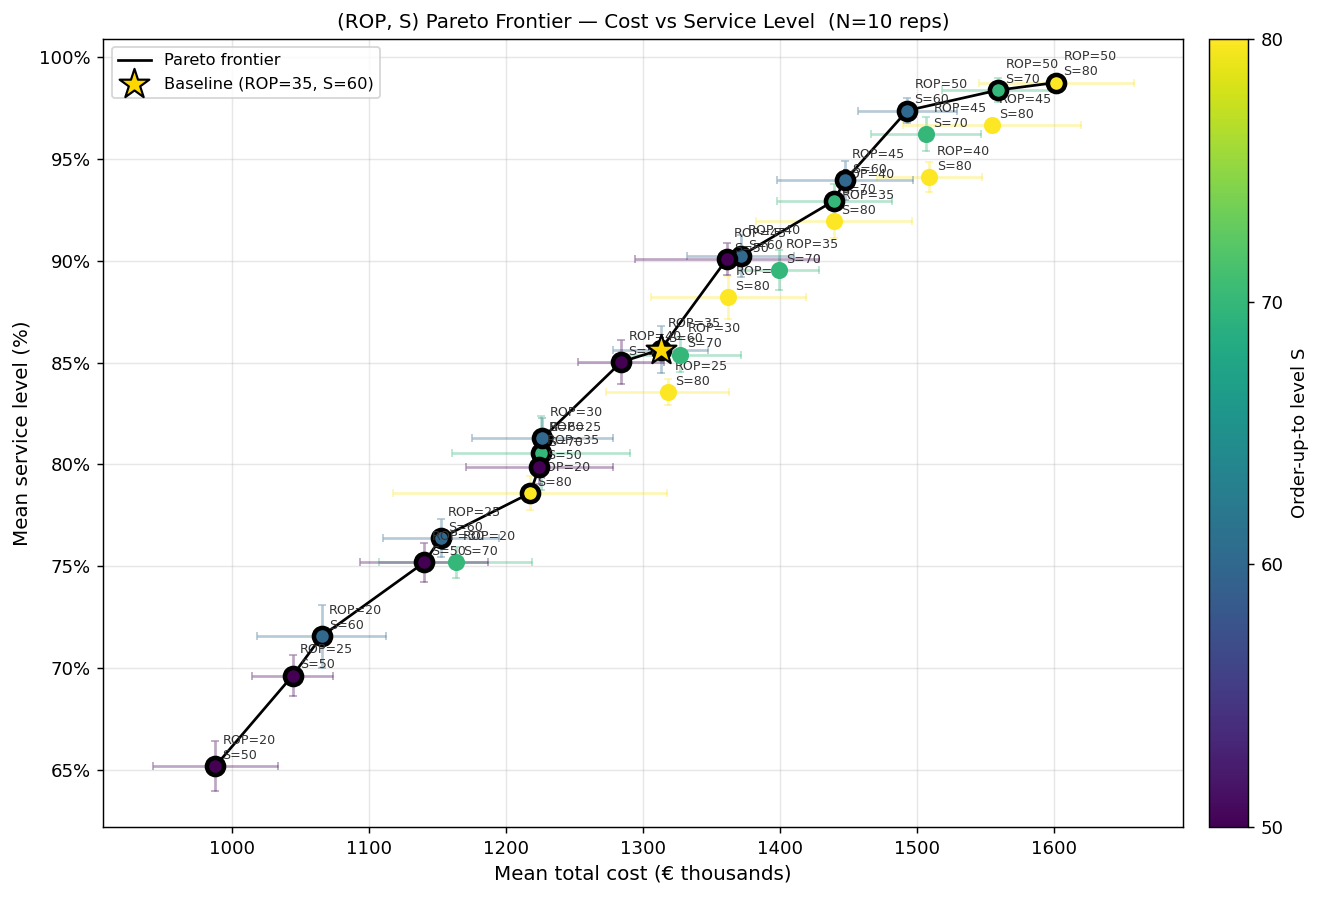

Pareto-optimal policies:
 ROP  S sl_mean  cost_mean
  20 50   65.2%   €987,800
  25 50   69.6% €1,044,209
  20 60   71.5% €1,065,338
  30 50   75.2% €1,140,341
  25 60   76.4% €1,152,490
  20 80   78.6% €1,217,583
  35 50   79.9% €1,224,357
  25 70   80.6% €1,225,773
  30 60   81.3% €1,226,406
  40 50   85.0% €1,284,141
  35 60   85.6% €1,312,887
  45 50   90.1% €1,361,115
  40 60   90.2% €1,371,212
  40 70   93.0% €1,439,381
  45 60   93.9% €1,447,368
  50 60   97.4% €1,492,852
  50 70   98.4% €1,559,137
  50 80   98.8% €1,601,549


In [12]:
ROP_GRID   = [20, 25, 30, 35, 40, 45, 50]
S_GRID     = [50, 60, 70, 80]
N_PARETO   = 10

records = []
for rop in ROP_GRID:
    for s in S_GRID:
        if rop >= s:
            continue
        p_var = Params(reorder_point=rop, max_stock=s, initial_stock=s)
        batch = [kpi_from_run(run(p_var, seed=k), p_var) for k in range(N_PARETO)]
        df_b  = pd.DataFrame(batch)
        records.append(dict(
            ROP       = rop,
            S         = s,
            sl_mean   = df_b.service_level.mean(),
            sl_std    = df_b.service_level.std(),
            cost_mean = df_b.total_cost.mean(),
            cost_std  = df_b.total_cost.std(),
        ))
df_pareto = pd.DataFrame(records)

# ── Pareto identification ─────────────────────────────────────────────────
def is_pareto_optimal(df):
    dominated = np.zeros(len(df), dtype=bool)
    vals = df[['sl_mean', 'cost_mean']].values
    for i in range(len(vals)):
        for j in range(len(vals)):
            if i == j:
                continue
            if vals[j, 0] >= vals[i, 0] and vals[j, 1] <= vals[i, 1]:
                if vals[j, 0] > vals[i, 0] or vals[j, 1] < vals[i, 1]:
                    dominated[i] = True
                    break
    return ~dominated

df_pareto['pareto'] = is_pareto_optimal(df_pareto)
df_front = df_pareto[df_pareto.pareto].sort_values('cost_mean')

# ── plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

s_vals   = sorted(df_pareto.S.unique())
cmap     = plt.cm.viridis
colors   = {s: cmap(i / (len(s_vals) - 1)) for i, s in enumerate(s_vals)}

for _, row in df_pareto.iterrows():
    c = colors[row.S]
    lw = 2.5 if row.pareto else 0.0
    ax.scatter(row.cost_mean / 1e3, row.sl_mean * 100,
               color=c, s=90, zorder=3,
               edgecolors='black' if row.pareto else c, linewidths=lw)
    ax.annotate(f"ROP={int(row.ROP)}\nS={int(row.S)}",
                xy=(row.cost_mean / 1e3, row.sl_mean * 100),
                xytext=(4, 4), textcoords='offset points', fontsize=7, color='#333333')
    ax.errorbar(row.cost_mean / 1e3, row.sl_mean * 100,
                xerr=row.cost_std / 1e3, yerr=row.sl_std * 100,
                fmt='none', color=c, alpha=0.35, capsize=2)

# Pareto frontier line
ax.plot(df_front.cost_mean / 1e3, df_front.sl_mean * 100,
        color='black', lw=1.5, ls='-', zorder=2, label='Pareto frontier')

# Baseline star
base_row = df_pareto[(df_pareto.ROP == BASELINE.reorder_point) & (df_pareto.S == BASELINE.max_stock)]
if not base_row.empty:
    ax.scatter(base_row.cost_mean / 1e3, base_row.sl_mean * 100,
               marker='*', s=300, color='gold', edgecolors='black', lw=1.2,
               zorder=5, label=f'Baseline (ROP={BASELINE.reorder_point}, S={BASELINE.max_stock})')

# Colorbar for S
sm = plt.cm.ScalarMappable(cmap=cmap,
     norm=plt.Normalize(vmin=min(s_vals), vmax=max(s_vals)))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Order-up-to level S', fontsize=10)
cbar.set_ticks(s_vals)

ax.set_xlabel('Mean total cost (€ thousands)', fontsize=11)
ax.set_ylabel('Mean service level (%)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0f}%'))
ax.set_title(f'(ROP, S) Pareto Frontier — Cost vs Service Level  (N={N_PARETO} reps)', fontsize=11)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Pareto-optimal policies:')
print(df_front[['ROP','S','sl_mean','cost_mean']].assign(
    sl_mean=lambda d: d.sl_mean.map('{:.1%}'.format),
    cost_mean=lambda d: d.cost_mean.map('€{:,.0f}'.format)).to_string(index=False))